In [2]:
import httpx
import time
import pandas as pd
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "yangheng/deberta-v3-base-absa-v1.1"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def aspect_sentiment(text, aspect, batch_size=16, max_length=512, stride=64):
    encoded = tokenizer(
        text,
        aspect,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_keys = ["input_ids", "attention_mask", "token_type_ids"]
    input_keys = [k for k in input_keys if k in encoded]

    all_probs = []

    with torch.inference_mode():
        n_chunks = encoded["input_ids"].shape[0]

        for start in range(0, n_chunks, batch_size):
            end = start + batch_size

            batch = {
                k: encoded[k][start:end].to(device)
                for k in input_keys
            }

            outputs = model(**batch)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs)

    avg_probs = torch.cat(all_probs, dim=0).mean(dim=0).cpu()

    return {
        model.config.id2label[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

Using device: mps


/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0629 21:28:06.860000 34856 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
print(aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters"))
sentiment = aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters")

post_sentiments = []
post_sentiment_degrees = []

post_sentiments.append(max(sentiment, key=sentiment.get))
post_sentiment_degrees.append(max(sentiment.values()))

print(post_sentiments[0], post_sentiment_degrees[0])

{'Negative': 0.9916238188743591, 'Neutral': 0.007077292539179325, 'Positive': 0.0012989335227757692}
Negative 0.9916238188743591


In [5]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/brightdata_social_exports/reddit_datacenters_posts.json")

with file_path.open("r", encoding="utf-8") as f:
    reddit_posts = json.load(f)

In [6]:
'''
post_sentiments = []
post_sentiment_degrees = []

a = 0
for r_post in reddit_posts:
    a += 1
    text = r_post["title"] + " " + r_post["description"]
    sentiment = aspect_sentiment(text, "datacenters")
    post_sentiments.append(max(sentiment, key=sentiment.get))
    post_sentiment_degrees.append(max(sentiment.values()))
    print("Posts scanned:", a, end="\r")
'''

'\npost_sentiments = []\npost_sentiment_degrees = []\n\na = 0\nfor r_post in reddit_posts:\n    a += 1\n    text = r_post["title"] + " " + r_post["description"]\n    sentiment = aspect_sentiment(text, "datacenters")\n    post_sentiments.append(max(sentiment, key=sentiment.get))\n    post_sentiment_degrees.append(max(sentiment.values()))\n    print("Posts scanned:", a, end="\r")\n'

In [7]:
'''
sentiments_backup = post_sentiments.copy()
sentiment_degrees_backup = post_sentiment_degrees.copy()

data = {
    "sentiments": post_sentiments,
    "sentiment_degrees": post_sentiment_degrees
}

with open("reddit_sentiments_backup.json", "w") as f:
    json.dump(data, f)
'''

'\nsentiments_backup = post_sentiments.copy()\nsentiment_degrees_backup = post_sentiment_degrees.copy()\n\ndata = {\n    "sentiments": post_sentiments,\n    "sentiment_degrees": post_sentiment_degrees\n}\n\nwith open("reddit_sentiments_backup.json", "w") as f:\n    json.dump(data, f)\n'

In [8]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/across_social_media_overall_sentiment_analysis/using_ABSA_CURRENT_TECHNIQUE/reddit_sentiments_backup.json")

with file_path.open("r", encoding="utf-8") as f:
    sentiments = json.load(f)

post_sentiments = sentiments["sentiments"]
post_sentiment_degrees = sentiments["sentiment_degrees"]

In [9]:
posts = pd.DataFrame(columns=["ids", "text", "date", "upvotes", "number of comments", "subreddit", "sentiment", "degree", "AWS", "Amazon", "Google", "Microsoft", "Azure", "Meta", "Oracle", "Equinix", "Digital Realty", "IBM", "Facebook", "Apple", "QTS", "Vantage", "CyrusOne", "CoreSite"])

post_ids = []
post_texts = []
post_dates = []
post_num_comments = []
post_upvotes = []
post_subreddits = []

a = 0

for r_post in reddit_posts:
    post_ids.append(r_post["post_id"])
    text = r_post["title"] + " " + r_post["description"]
    post_texts.append(text)
    post_dates.append(r_post["date_posted"])
    post_num_comments.append(r_post["num_comments"])
    post_upvotes.append(r_post["num_upvotes"])
    post_subreddits.append(r_post["community_name"])


posts["ids"] = post_ids
posts["text"] = post_texts
posts["date"] = post_dates
posts["number of comments"] = post_num_comments
posts["upvotes"] = post_upvotes
posts["subreddit"] = post_subreddits
posts["sentiment"] = post_sentiments
posts["degree"] = post_sentiment_degrees

In [10]:
posts = posts.astype({
    "ids": "string",
    "text": "string",
    "date": "string",
    "upvotes": "int64",
    "number of comments": "int64",
    "subreddit": "string",
    "sentiment": "string",
    "degree": "float64",
    "AWS": "bool",
    "Amazon": "bool",
    "Google": "bool",
    "Microsoft": "bool",
    "Azure": "bool",
    "Meta": "bool",
    "Oracle": "bool",
    "Equinix": "bool",
    "Digital Realty": "bool",
    "IBM": "bool",
    "Facebook": "bool",
    "Apple": "bool",
    "QTS": "bool",
    "Vantage": "bool",
    "CyrusOne": "bool",
    "CoreSite": "bool"
})

In [11]:
company_terms = ["AWS","Amazon","Google","Microsoft","Azure","Meta","Oracle","Equinix","Digital Realty","IBM","Facebook","Apple","QTS","Vantage","CyrusOne","CoreSite"]

for c in company_terms:
    posts[c] = posts["text"].str.contains(rf'\b{re.escape(c)}\b', case=False, na=False)

posts_with_company = posts[posts[company_terms].any(axis=1)]
posts_with_company.head()

,ids,text,date,upvotes,number of comments,subreddit,sentiment,degree,AWS,Amazon,...,Oracle,Equinix,Digital Realty,IBM,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite
0,t3_1cbn1oq,2023 Stock Market Review: A Dynamic Visualizat...,2024-04-24T02:22:08.415Z,1,0,financialsignals,Positive,0.902702,False,False,...,False,False,False,False,True,False,False,False,False,False
1,t3_1p2azqr,NVIDIA’s Q3 Epic Earnings Report: 4 Signals Yo...,2025-11-20T18:33:33.351Z,49,11,NvidiaStock,Positive,0.494226,False,True,...,False,False,False,False,False,False,False,False,False,False
3,t3_1rumhb6,1 Artificial Intelligence (AI) Stock I'd Never...,2026-03-15T19:00:08.639Z,1,0,RWATimes,Neutral,0.803264,False,False,...,False,False,False,False,False,False,False,False,False,False
6,t3_1p69avj,Top 10 Weekly Move Rankings - 2025-11-25 Top 1...,2025-11-25T10:42:34.540Z,1,0,AIPortfolios,Positive,0.823084,False,False,...,False,False,False,False,False,False,False,False,False,False
9,t3_1ntfepl,"AI Weekly: OpenAI’s 10‑GW push, Anthropic’s gl...",2025-09-29T11:25:45.129Z,1,0,software_soloprenures,Positive,0.599796,False,True,...,True,False,False,False,False,False,False,False,False,False


In [12]:
def remove_links(text):
    # Regex pattern to find typical URLs (http/https followed by non-whitespace characters)
    url_pattern = re.compile(r'\[https?://\S+\]|\(https?://\S+\)|\[www\.\S+\]|\(www\.\S+\)')
    # Replace found URLs with an empty string
    cleaned_text = url_pattern.sub('', text)
    return cleaned_text

posts["text"] = posts["text"].apply(remove_links)

In [13]:
len(posts)
posts.head()

,ids,text,date,upvotes,number of comments,subreddit,sentiment,degree,AWS,Amazon,...,Oracle,Equinix,Digital Realty,IBM,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite
0,t3_1cbn1oq,2023 Stock Market Review: A Dynamic Visualizat...,2024-04-24T02:22:08.415Z,1,0,financialsignals,Positive,0.902702,False,False,...,False,False,False,False,True,False,False,False,False,False
1,t3_1p2azqr,NVIDIA’s Q3 Epic Earnings Report: 4 Signals Yo...,2025-11-20T18:33:33.351Z,49,11,NvidiaStock,Positive,0.494226,False,True,...,False,False,False,False,False,False,False,False,False,False
2,t3_1kp6tq0,Indianapolis residents push back against data ...,2025-05-17T23:56:07.061Z,394,52,Indiana,Neutral,0.762514,False,False,...,False,False,False,False,False,False,False,False,False,False
3,t3_1rumhb6,1 Artificial Intelligence (AI) Stock I'd Never...,2026-03-15T19:00:08.639Z,1,0,RWATimes,Neutral,0.803264,False,False,...,False,False,False,False,False,False,False,False,False,False
4,t3_1ni16na,Cloud hosting economico (kimsufi vs hetzner) B...,2025-09-15T23:09:02.330Z,8,21,ItalyInformatica,Neutral,0.655257,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
print(posts.columns)

Index(['ids', 'text', 'date', 'upvotes', 'number of comments', 'subreddit',
       'sentiment', 'degree', 'AWS', 'Amazon', 'Google', 'Microsoft', 'Azure',
       'Meta', 'Oracle', 'Equinix', 'Digital Realty', 'IBM', 'Facebook',
       'Apple', 'QTS', 'Vantage', 'CyrusOne', 'CoreSite'],
      dtype='object')


In [15]:
## total average sentiment calculation

pos = posts.loc[posts["sentiment"] == "Positive", "degree"].sum()
neg = posts.loc[posts["sentiment"] == "Negative", "degree"].sum()
total = posts["degree"].sum()
print("Average sentiment for all of reddit: ", (pos-neg)/total)

Average sentiment for all of reddit:  0.15153009286520158


In [16]:
pos = posts.loc[posts["sentiment"] == "Positive"]
neg = posts.loc[posts["sentiment"] == "Negative"]
neutral = posts.loc[posts["sentiment"] == "Neutral"]

print("Percent of posts that are neutral:", len(neutral)/len(posts))
print("Percent of posts that are negative:", len(neg)/len(posts))
print("Percent of posts that are positive:", len(pos)/len(posts))

really_pos = pos.loc[posts["degree"] > 0.90]
really_neg = neg.loc[posts["degree"] > 0.90]

if len(neg) != 0:
    print("Percent of negative posts that are really negative:", len(really_neg)/len(neg))
if len(pos) != 0:
    print("Percent of positive posts that are really positive:", len(really_pos)/len(pos))

Percent of posts that are neutral: 0.3260790273556231
Percent of posts that are negative: 0.25659574468085106
Percent of posts that are positive: 0.41732522796352584
Percent of negative posts that are really negative: 0.1802890310352997
Percent of positive posts that are really positive: 0.11252731245447924


In [23]:
def avg_sentiment_calculation(dataset):
    pos = dataset.loc[dataset["sentiment"] == "Positive", "degree"].sum()
    neg = dataset.loc[dataset["sentiment"] == "Negative", "degree"].sum()
    total = dataset["degree"].sum()
    if total != 0:
        return (pos-neg)/total
    else:
        return 0

posts['year'] = pd.to_datetime(posts['date']).dt.year

year_datasets = {year: posts[posts['year'] == year] for year in range(2010, 2027)}

sum = 0

for i in range(2010, 2027):
    print(f"Number of posts from {i}: ", len(year_datasets[i]))
    if(len(year_datasets[i]) != 0):
        print(f"Average sentiment for reddit posts from {i}: ", avg_sentiment_calculation(year_datasets[i]))
    sum += len(year_datasets[i])

print(sum)

Number of posts from 2010:  0
Number of posts from 2011:  2
Average sentiment for reddit posts from 2011:  -0.34300905765093076
Number of posts from 2012:  12
Average sentiment for reddit posts from 2012:  0.01530672664144669
Number of posts from 2013:  14
Average sentiment for reddit posts from 2013:  0.06691381018792893
Number of posts from 2014:  21
Average sentiment for reddit posts from 2014:  -0.1606959138292004
Number of posts from 2015:  26
Average sentiment for reddit posts from 2015:  -0.09111730245510392
Number of posts from 2016:  44
Average sentiment for reddit posts from 2016:  -0.14629519801886212
Number of posts from 2017:  51
Average sentiment for reddit posts from 2017:  0.033843561562171935
Number of posts from 2018:  60
Average sentiment for reddit posts from 2018:  0.17037018974899992
Number of posts from 2019:  107
Average sentiment for reddit posts from 2019:  0.053965509212228514
Number of posts from 2020:  123
Average sentiment for reddit posts from 2020:  -0.0

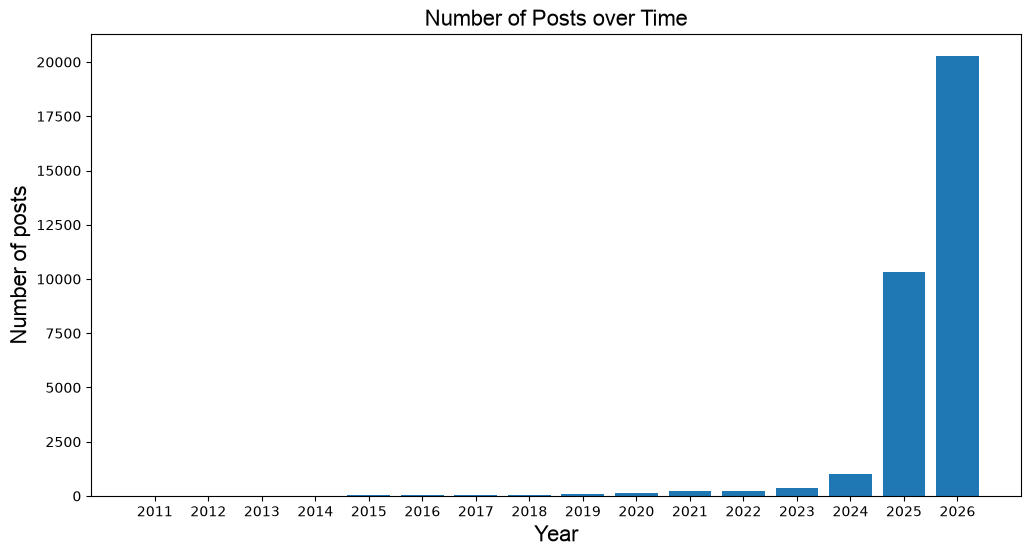

In [26]:
categories = ["2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [len(year_datasets[2011]), len(year_datasets[2012]), len(year_datasets[2013]), len(year_datasets[2014]), len(year_datasets[2015]), len(year_datasets[2016]), len(year_datasets[2017]), len(year_datasets[2018]), len(year_datasets[2019]), len(year_datasets[2020]), len(year_datasets[2021]), len(year_datasets[2022]), len(year_datasets[2023]), len(year_datasets[2024]), len(year_datasets[2025]), len(year_datasets[2026])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Number of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Number of posts",
    fontsize=16,
    fontname="Arial"
)

plt.show()

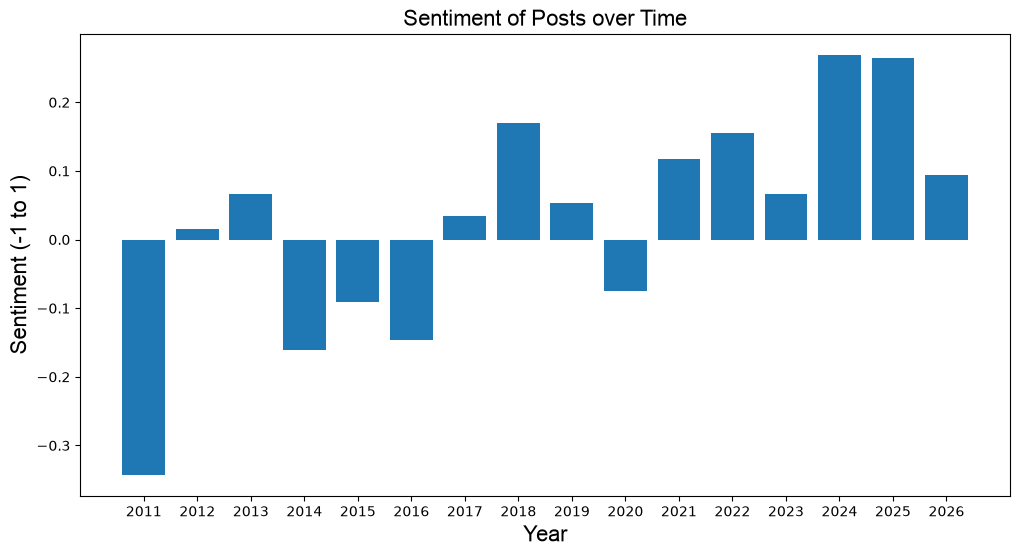

In [27]:
categories = ["2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [avg_sentiment_calculation(year_datasets[2011]), avg_sentiment_calculation(year_datasets[2012]), avg_sentiment_calculation(year_datasets[2013]), avg_sentiment_calculation(year_datasets[2014]), avg_sentiment_calculation(year_datasets[2015]), avg_sentiment_calculation(year_datasets[2016]), avg_sentiment_calculation(year_datasets[2017]), avg_sentiment_calculation(year_datasets[2018]), avg_sentiment_calculation(year_datasets[2019]), avg_sentiment_calculation(year_datasets[2020]), avg_sentiment_calculation(year_datasets[2021]), avg_sentiment_calculation(year_datasets[2022]), avg_sentiment_calculation(year_datasets[2023]), avg_sentiment_calculation(year_datasets[2024]), avg_sentiment_calculation(year_datasets[2025]), avg_sentiment_calculation(year_datasets[2026])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Sentiment of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Sentiment (-1 to 1)",
    fontsize=16,
    fontname="Arial"
)
plt.show()

In [20]:
def sentiment_by_company(company1, company2=None):
    company_posts = posts[
        (posts[company1] == True) | (posts[company2] == True) if company2 else (posts[company1] == True)
    ]
    return avg_sentiment_calculation(company_posts)

print("Number of Amazon-related posts:", len(posts[posts["AWS"] == True]) + len(posts[posts["Amazon"] == True]))
print("Average sentiment of AWS-related posts:", sentiment_by_company("AWS", "Amazon"))
print("Number of Google-related posts:", len(posts[posts["Google"] == True]))
print("Average sentiment of Google-related posts:", sentiment_by_company("Google"))
print("Number of Microsoft-related posts:", len(posts[posts["Microsoft"] == True]) + len(posts[posts["Azure"] == True]))
print("Average sentiment of Microsoft-related posts:", sentiment_by_company("Microsoft", "Azure"))
print("Number of Meta-related posts:", len(posts[posts["Meta"] == True]) + len(posts[posts["Facebook"] == True]))
print("Average sentiment of Meta-related posts:", sentiment_by_company("Meta"))
print("Number of Oracle-related posts:", len(posts[posts["Oracle"] == True]))
print("Average sentiment of Oracle-related posts:", sentiment_by_company("Oracle"))
print("Number of Equinix-related posts:", len(posts[posts["Equinix"] == True]))
print("Average sentiment of Equinix-related posts:", sentiment_by_company("Equinix"))
print("Number of Digital Realty-related posts:", len(posts[posts["Digital Realty"] == True]))
print("Average sentiment of Digital Realty-related posts:", sentiment_by_company("Digital Realty"))
print("Number of IBM-related posts:", len(posts[posts["IBM"] == True]))
print("Average sentiment of IBM-related posts:", sentiment_by_company("IBM"))
print("Number of Apple-related posts:", len(posts[posts["Apple"] == True]))
print("Average sentiment of Apple-related posts:", sentiment_by_company("Apple"))
print("Number of QTS-related posts:", len(posts[posts["QTS"] == True]))
print("Average sentiment of QTS-related posts:", sentiment_by_company("QTS"))
print("Number of Vantage-related posts:", len(posts[posts["Vantage"] == True]))
print("Average sentiment of Vantage-related posts:", sentiment_by_company("Vantage"))
print("Number of CyrusOne-related posts:", len(posts[posts["CyrusOne"] == True]))
print("Average sentiment of CyrusOne-related posts:", sentiment_by_company("CyrusOne"))
print("Number of CoreSite-related posts:", len(posts[posts["CoreSite"] == True]))
print("Average sentiment of CoreSite-related posts:", sentiment_by_company("CoreSite"))

Number of Amazon-related posts: 4844
Average sentiment of AWS-related posts: 0.29473557729949373
Number of Google-related posts: 4553
Average sentiment of Google-related posts: 0.2674005893695457
Number of Microsoft-related posts: 4436
Average sentiment of Microsoft-related posts: 0.30425775879141626
Number of Meta-related posts: 3476
Average sentiment of Meta-related posts: 0.28078418166170793
Number of Oracle-related posts: 1348
Average sentiment of Oracle-related posts: 0.19589672273574674
Number of Equinix-related posts: 134
Average sentiment of Equinix-related posts: 0.4677207148125374
Number of Digital Realty-related posts: 94
Average sentiment of Digital Realty-related posts: 0.6425744581360164
Number of IBM-related posts: 727
Average sentiment of IBM-related posts: 0.5868196959975036
Number of Apple-related posts: 1549
Average sentiment of Apple-related posts: 0.3700646331572564
Number of QTS-related posts: 53
Average sentiment of QTS-related posts: -0.02949589605753733
Number 

In [21]:
def analysis_of_viral_posts(min):
    viral_posts = posts.loc[posts["upvotes"] >= min]
    non_viral_posts = posts.loc[posts["upvotes"] < min]
    print("What's considered viral: posts with over", min, "upvotes")
    print("Number of viral posts:", len(viral_posts))
    print("Average sentiment of viral posts:", avg_sentiment_calculation(viral_posts))
    print("Average sentiment of non-viral posts:", avg_sentiment_calculation(non_viral_posts))
    print("Amount percent of viral posts that are polar (degree) > 0.90: ", len(viral_posts.loc[viral_posts["degree"] > 0.90])/len(viral_posts))
    print("Percent of viral posts that are negative: ", (len(viral_posts.loc[viral_posts["sentiment"] == "Negative"]))/len(viral_posts))
    print("Percent of non-viral posts that are negative: ", (len(non_viral_posts.loc[non_viral_posts["sentiment"] == "Negative"]))/(len(non_viral_posts)))

analysis_of_viral_posts(500)
print("\n")
analysis_of_viral_posts(1000)
print("\n")
analysis_of_viral_posts(2000)
print("\n")
analysis_of_viral_posts(5000)

What's considered viral: posts with over 500 upvotes
Number of viral posts: 807
Average sentiment of viral posts: -0.4182139397781738
Average sentiment of non-viral posts: 0.16614541922491102
Amount percent of viral posts that are polar (degree) > 0.90:  0.18587360594795538
Percent of viral posts that are negative:  0.5824039653035935
Percent of non-viral posts that are negative:  0.2484030785529555


What's considered viral: posts with over 1000 upvotes
Number of viral posts: 407
Average sentiment of viral posts: -0.4321062961022731
Average sentiment of non-viral posts: 0.15885581528896214
Amount percent of viral posts that are polar (degree) > 0.90:  0.14987714987714987
Percent of viral posts that are negative:  0.5945945945945946
Percent of non-viral posts that are negative:  0.25236204721016836


What's considered viral: posts with over 2000 upvotes
Number of viral posts: 174
Average sentiment of viral posts: -0.49550907889482193
Average sentiment of non-viral posts: 0.154946308328